In [1]:
import pandas as pd

datos = pd.read_excel("Datos_2025_155.xlsx")
print(datos.shape)

(18717, 69)


Como las fechas estan en la base original como texto, así: 1/04/2025 12:00:00 a. m.. Python no puede restar texto. Primero hay que convertirlas en fechas, indicando que el día va primero.
Como la variable trae espacios y hora que no dejan hacer el calculo .str[:10] tome solo los 10 caracteres de la fecha, .str.strip() borre espacios y le indique el formato correcto de fecha format="%d/%m/%Y", cree mi variable Y calculando la diferencia entre fecha de consulta y fecha de inicio de sintomas = datos["demora"] = y verifique .describe()

In [2]:
datos["INI_SIN"] = pd.to_datetime(datos["INI_SIN"].str[:10].str.strip(), format="%d/%m/%Y")
datos["FEC_CON"] = pd.to_datetime(datos["FEC_CON"].str[:10].str.strip(), format="%d/%m/%Y")

datos["demora"] = (datos["FEC_CON"] - datos["INI_SIN"]).dt.days

print(datos["demora"].describe())

count    18717.000000
mean        87.009029
std        207.348777
min          0.000000
25%         12.000000
50%         36.000000
75%         92.000000
max       8087.000000
Name: demora, dtype: float64


la mediana es 36 días y el promedio 87 indica que hay datos exremos tirando del promedio hacia arriba, por lo cual se procede a hacer depuracion de datos que por error sesgarian el analisis: Demora mayor a 365 días	673 (3,6 %). Una demora de más de un año entre síntomas y consulta probablemente es error de digitación o un síntoma antiguo que no corresponde al episodio; se excluyen tambien Estrato en blanco 734 y Residencia en el exterior 17

In [3]:
datos["estrato"] = datos["estrato"].astype(str).str.strip()

limpios = datos[
    (datos["demora"] <= 365) &
    (datos["estrato"] != "") &
    (datos["Departamento_residencia"] != "EXTERIOR")
]

print(len(datos) - len(limpios), "casos excluidos")
print(limpios["demora"].describe())

1391 casos excluidos
count    17326.000000
mean        60.898765
std         71.411911
min          0.000000
25%         12.000000
50%         34.000000
75%         83.000000
max        365.000000
Name: demora, dtype: float64


Como el modelo solo entiende numero pero mis "pistas# son texto las voy a recategorizar creando columnas por cada categoria de 1 y 0  es decir respondiendo a una pregunta: es del valle 1 o 0, asi con los departamentos area, regimen y eapb. Dicho esto Bogotá, contributivo, EPS005 y cabecera quedaron como referencia.  
pd.get_dummies es la herramienta que utilice para crear estas columnas y .drop borra una columna de cada grupo: Bogotá, contributivo, la EAPB más grande y cabecera municipal.lo anterior con asesoria de la IA.

In [4]:
X = limpios[["Departamento_residencia", "EDAD", "TIP_SS", "COD_ASE", "estrato", "AREA"]].copy()
X["estrato"] = X["estrato"].astype(int)
y = limpios["demora"]

X = pd.get_dummies(X, columns=["Departamento_residencia", "TIP_SS", "COD_ASE", "AREA"])
X = X.drop(columns=["Departamento_residencia_BOGOTA", "TIP_SS_C", "COD_ASE_EPS005", "AREA_1"])

print(X.shape)

(17326, 128)


separar casos para aprender y para examinar: Sacar una muestra al azar, para que no queden todas de las mismas caracteristicas, que para mi ejercicio de 17.326 casos:
75 % (12.994 casos) para aprender: el modelo ve las pistas y la demora real, y busca la relación.
25 % (4.332 casos) se guardan para el examen.
random_state=42 el sorteo sale identico al volver a correr el codigo

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(X_train.shape, X_test.shape)

(12994, 128) (4332, 128)


El modelo aprende con el 75 %, y después predice la demora del 25 % que nunca vio. Comparamos lo que adivinó contra lo que pasó en realidad.

In [6]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

comparacion = pd.DataFrame({"Demora_real": y_test, "Demora_predicha": y_pred})
comparacion.head(10)

,Demora_real,Demora_predicha
10724,69,50.441061
5965,11,61.185108
14695,0,31.846700
7401,14,32.332491
8906,109,103.394621
16355,0,37.835487
12120,37,39.473740
4568,104,65.038144
5074,154,78.861541
935,17,57.738245


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

MAE : 48.85
MSE : 4523.21
RMSE: 67.25
R²  : 0.062


con un R2 de 0,062 significa que el 6,2 %. De todas las diferencias en demora en la notificacion entre una paciente y otra, las seis variables explican solo el 6 %. El otro 94 % depende de cosas que no están en la base.

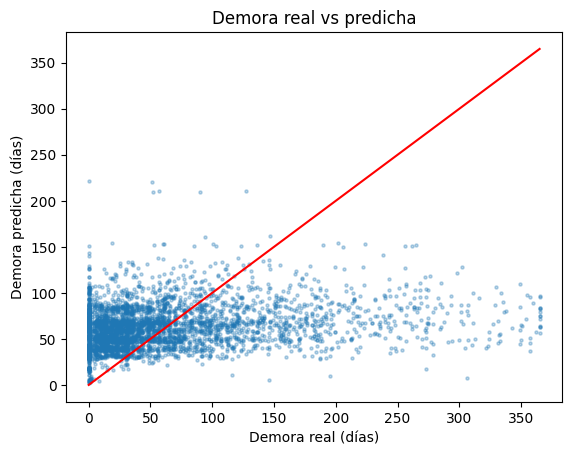

In [8]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.3, s=5)
plt.plot([0, 365], [0, 365], color="red")
plt.xlabel("Demora real (días)")
plt.ylabel("Demora predicha (días)")
plt.title("Demora real vs predicha")
plt.show()

las demoras reales van de 0 a 365 días, pero el modelo predijo casi siempre entre 31 y 103 días por eso los puntos formaron una franja horizontal que cruza la recta roja, en vez de seguirla.

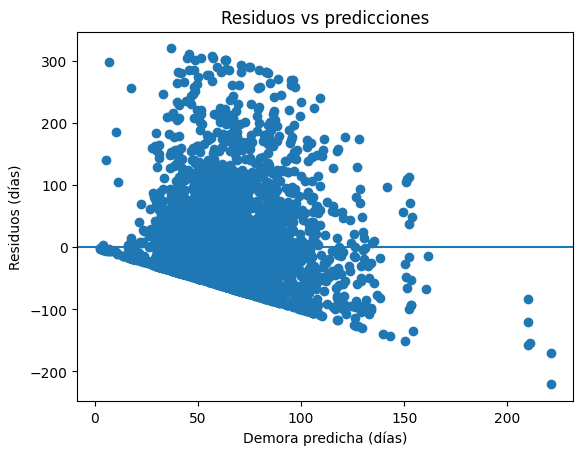

In [9]:
residuos = y_test - y_pred

plt.scatter(y_pred, residuos)
plt.axhline(0)
plt.xlabel("Demora predicha (días)")
plt.ylabel("Residuos (días)")
plt.title("Residuos vs predicciones")
plt.show()

El error crece a medida que la predicción es más alta, hasta llegar a 103 que fue casi siempre el tope

In [10]:
eda = limpios[["EDAD", "estrato", "demora"]].copy()
eda["estrato"] = eda["estrato"].astype(int)

print(eda.describe())
print(eda.corr())

               EDAD       estrato        demora
count  17326.000000  17326.000000  17326.000000
mean      52.453365      2.228270     60.898765
std       15.524697      1.009113     71.411911
min       16.000000      1.000000      0.000000
25%       40.000000      2.000000     12.000000
50%       51.000000      2.000000     34.000000
75%       64.000000      3.000000     83.000000
max      105.000000      6.000000    365.000000
             EDAD  estrato    demora
EDAD     1.000000  0.06752  0.036371
estrato  0.067520  1.00000 -0.063060
demora   0.036371 -0.06306  1.000000


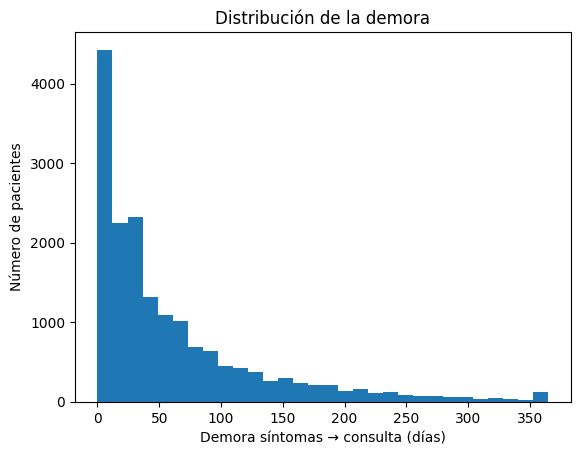

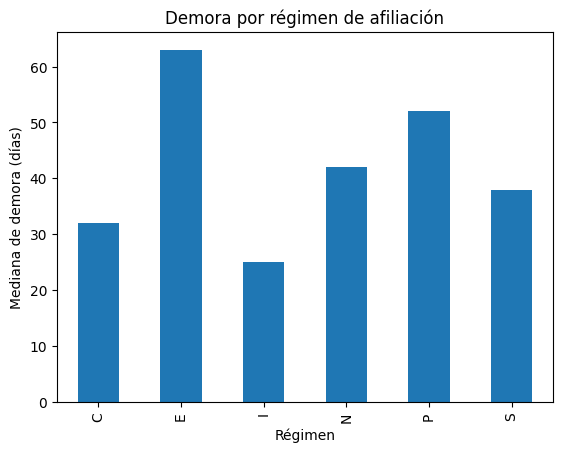

In [11]:
plt.hist(limpios["demora"], bins=30)
plt.xlabel("Demora síntomas → consulta (días)")
plt.ylabel("Número de pacientes")
plt.title("Distribución de la demora")
plt.show()

limpios.groupby("TIP_SS")["demora"].median().plot(kind="bar")
plt.xlabel("Régimen")
plt.ylabel("Mediana de demora (días)")
plt.title("Demora por régimen de afiliación")
plt.show()

Histograma: la mayoría amontonada a la izquierda y una cola larga hacia la derecha. Es la asimetría que explica por qué la media (61) supera a la mediana (34).
Barras: contributivo 32 días de mediana, subsidiado 38, y particular 52.

In [13]:
coeficientes = pd.Series(modelo.coef_, index=X.columns)
print(coeficientes.loc[["EDAD", "estrato", "TIP_SS_S", "AREA_2", "AREA_3"]].round(2))

EDAD         0.10
estrato     -0.68
TIP_SS_S    13.24
AREA_2       5.45
AREA_3      10.49
dtype: float64


Edad: por cada año más de edad, la demora sube 0,10 días
estrato: por cada estrato que sube, la demora baja 0,68 días
Tipo SS_S: una paciente del régimen subsidiado tiene, en promedio, 13 días más de demora que una del contributivo

In [14]:
dep = coeficientes[coeficientes.index.str.startswith("Departamento_residencia_")]
print(dep.sort_values().round(1).head(5))
print(dep.sort_values().round(1).tail(5))

Departamento_residencia_VAUPES      -48.0
Departamento_residencia_CAQUETA     -47.1
Departamento_residencia_VICHADA     -40.8
Departamento_residencia_GUAINIA     -33.2
Departamento_residencia_RISARALDA   -21.0
dtype: float64
Departamento_residencia_MAGDALENA    45.6
Departamento_residencia_CHOCO        45.7
Departamento_residencia_CESAR        53.1
Departamento_residencia_GUAJIRA      57.8
Departamento_residencia_AMAZONAS     73.7
dtype: float64


Departamentos con más y menos demora que el comparador que para este caso es Bogotá, sin embargo Amazonas, Vaupés, Vichada y Guainía tienen muy pocos casos en comparacion con bogota y cualquier caso pesa mucho mas que los casos de bogota (estimacion inestable)